# FER CNN — Google Colab Notebook




In [ ]:

# SETUP
import os, math, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


## 2) Load dataset



In [ ]:

# LOAD DATA 
CSV_PATH = "train.csv"

df = pd.read_csv(CSV_PATH)
display(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


Shape: (28709, 2)
Columns: ['emotion', 'pixels']


## 3) Remove *Disgust* and remap labels

FER2013 label mapping is typically:
- 0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral




In [ ]:

# REMOVE DISGUST 
DISGUST_LABEL = 1

if "emotion" not in df.columns or "pixels" not in df.columns:
    raise ValueError("Expected columns: 'emotion' and 'pixels'. Found: " + str(df.columns.tolist()))

# Remove disgust rows
df = df[df["emotion"] != DISGUST_LABEL].copy()
print("After removing disgust:", df.shape)

# Remap remaining labels
unique_labels = sorted(df["emotion"].unique().tolist())
label_map = {old:i for i, old in enumerate(unique_labels)}
inv_label_map = {v:k for k,v in label_map.items()}

df["label"] = df["emotion"].map(label_map).astype(int)
num_classes = df["label"].nunique()

print("Unique original labels (after removal):", unique_labels)
print("Label map:", label_map)
print("Num classes:", num_classes)


After removing disgust: (28273, 2)
Unique original labels (after removal): [0, 2, 3, 4, 5, 6]
Label map: {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
Num classes: 6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4) Parse pixels ➜ images



In [ ]:

#  PARSE PIXELS 
IMG_SIZE = 48  # FER2013 is 48x48

def pixels_to_image(pixels_str, img_size=IMG_SIZE):
    arr = np.fromstring(pixels_str, sep=" ", dtype=np.float32)
    if arr.size != img_size * img_size:
        raise ValueError(f"Unexpected pixel count {arr.size}. Expected {img_size*img_size}. "
                         f"Update IMG_SIZE if your data isn't {img_size}x{img_size}.")
    arr = arr.reshape((img_size, img_size, 1))
    return arr

# Sanity check (first row)
sample_img = pixels_to_image(df.iloc[0]["pixels"])
print("Sample image shape:", sample_img.shape, "min/max:", sample_img.min(), sample_img.max())


Sample image shape: (48, 48, 1) min/max: 11.0 210.0


## 5) Train/Val split




In [ ]:
# SPLIT 
from sklearn.model_selection import train_test_split

if "label" not in df.columns:
    raise ValueError("Expected df['label'] to exist")

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_df), "Val size:", len(val_df))
print("Train label counts:\n", train_df["label"].value_counts().sort_index())
print("Val label counts:\n", val_df["label"].value_counts().sort_index())


## 6) Build tf.data pipeline with augmentation




In [ ]:

# DATA PIPELINE 
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64

def make_dataset(dataframe, training: bool):
    pixels = dataframe["pixels"].values
    labels = dataframe["label"].values.astype(np.int32)

    def gen():
        for p, y in zip(pixels, labels):
            img = pixels_to_image(p)
            yield img, y

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    # Normalize to 0..1
    ds = ds.map(lambda x,y: (x/255.0, y), num_parallel_calls=AUTOTUNE)

    if training:
        # FER augmentations
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomZoom(0.10, 0.10),
            layers.RandomContrast(0.15),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)


## 7) Class weights

In [ ]:

# CLASS WEIGHTS 
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(num_classes)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"].values)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)


Class weights: {0: 1.1794267765999216, 1: 1.1502967643116984, 2: 0.6530789716832437, 3: 0.9754830329598961, 4: 1.486209029066172, 5: 0.94913112164297}


## 8) CNN Model


In [ ]:

# MODEL 
def conv_block(x, filters, kernel=3, drop=0.20, l2=1e-4):
    x = layers.Conv2D(filters, kernel, padding="same",
                      kernel_regularizer=keras.regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, kernel, padding="same",
                      kernel_regularizer=keras.regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(drop)(x)
    return x

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
x = inputs

x = conv_block(x, 32, drop=0.20, l2=1e-4)
x = conv_block(x, 64, drop=0.25, l2=1e-4)
x = conv_block(x, 128, drop=0.30, l2=1e-4)

# extra block if underfitting occurs
# x = conv_block(x, 192, drop=0.35, l2=1e-4)

x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 585,958 (2.24 MB)

 Trainable params: 584,550 (2.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 9) Train




In [ ]:

# TRAIN 
EPOCHS = 60

try:
    optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)
    print("Using AdamW")
except Exception:
    optimizer = keras.optimizers.Adam(learning_rate=3e-4)
    print("Using Adam")

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Using AdamW
Epoch 1/60
    376/Unknown 80s 144ms/step - accuracy: 0.2218 - loss: 1.8690

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from -inf to 0.20373, saving model to best_model.keras
376/376 ━━━━━━━━━━━━━━━━━━━━ 88s 163ms/step - accuracy: 0.2219 - loss: 1.8688 - val_accuracy: 0.2037 - val_loss: 2.0661 - learning_rate: 3.0000e-04
Epoch 2/60
374/376 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.3241 - loss: 1.6895
Epoch 2: val_accuracy improved from 0.20373 to 0.36312, saving model to best_model.keras
376/376 ━━━━━━━━━━━━━━━━━━━━ 57s 135ms/step - accuracy: 0.3242 - loss: 1.6893 - val_accuracy: 0.3631 - val_loss: 1.5851 - learning_rate: 3.0000e-04
Epoch 3/60
374/376 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3964 - loss: 1.5688
Epoch 3: val_accuracy did not improve from 0.36312
376/376 ━━━━━━━━━━━━━━━━━━━━ 82s 198ms/step - accuracy: 0.3966 - loss: 1.5686 - val_accuracy: 0.3461 - val_loss: 1.7932 - learning_rate: 3.0000e-04
Epoch 4/60
376/376 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4460 - loss: 1.4667
Epoch 4: val_accuracy improved from 0.36312 to 0.48904, saving mo

## 10) Learning curves

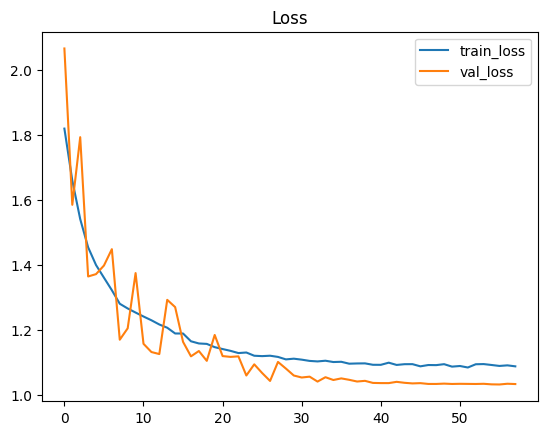

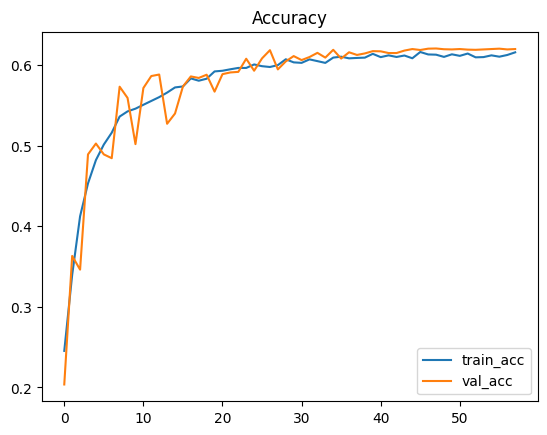

In [ ]:

# CURVES 
hist = history.history
plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()


## 11) Evaluation + Confusion Matrix

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Validation accuracy: 0.6204  |  val loss: 1.0340

Classification report:

              precision    recall  f1-score   support

           0     0.5579    0.5710    0.5644       599
           1     0.5431    0.3073    0.3925       615
           2     0.8569    0.8078    0.8316      1082
           3     0.5202    0.4793    0.4989       724
           4     0.6375    0.7647    0.6953       476
           5     0.5039    0.6913    0.5829       745

    accuracy                         0.6204      4241
   macro avg     0.6033    0.6035    0.5943      4241
weighted avg     0.6250    0.6204    0.6144      4241



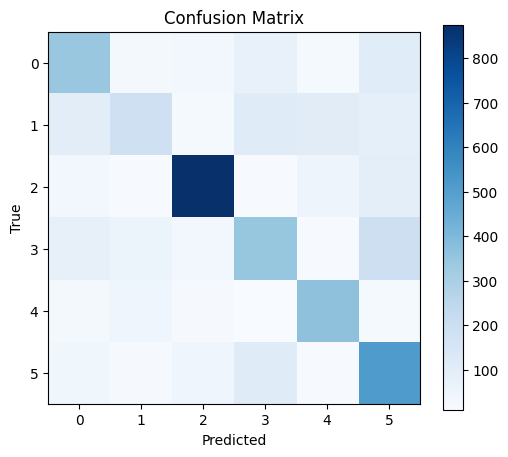

Label mapping (new -> original): {0: 0, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6}


In [ ]:

# Evaluation
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Validation accuracy: {val_acc:.4f}  |  val loss: {val_loss:.4f}")

# Predictions
y_true = val_df["label"].values.astype(int)
y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues') 
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

print("Label mapping (new -> original):", inv_label_map)


## 12) Save model + mapping


In [ ]:

# SAVE 
import json

model.save("facial_model.keras")

with open("label_map.json", "w") as f:
    json.dump({"old_to_new": label_map, "new_to_old": inv_label_map}, f, indent=2)

print("Saved: facial_model.keras")


In [ ]:
model.save('facial_model.h5')
print("Model saved as facial_model.h5")